# Image Classification — Waste Detection with CNN and Grad-CAM

## Github repo: https://github.com/ne-he/Image-Classification-DL.git

**Dataset:** TrashNet (dataset-resized) — 6 classes: cardboard, glass, metal, paper, plastic, trash  
**Approach:** Baseline CNN → Transfer Learning with MobileNetV2 + Grad-CAM Visualization  
**Framework:** TensorFlow / Keras

## 0. Install and Import Libraries

In [1]:
!pip install -q tensorflow scikit-learn matplotlib seaborn opencv-python-headless

In [2]:
import os
import io
import cv2
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import tensorflow as tf

from PIL import Image
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load Dataset from Remote Server

Dataset diambil dari server lokal yang di-expose via VS Code Dev Tunnel.  
Struktur direktori: `dataset-resized/{class_name}/{image_file}`

Script di bawah mengunduh seluruh gambar dari server ke memori lokal Colab, kemudian menyimpannya ke disk agar bisa digunakan oleh `ImageDataGenerator`.

In [3]:
import requests, zipfile, io

url = "https://mdl3jdvn-8000.asse.devtunnels.ms/dataset-resized.zip"
print("Downloading zip...")
resp = requests.get(url, timeout=300)
print("Extracting...")
with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    z.extractall("/content/")
print("Done.")

Extracting...
Done.


In [4]:
for cls in sorted(os.listdir("/content/dataset-resized")):
    path = f"/content/dataset-resized/{cls}"
    if os.path.isdir(path):
        print(f"{cls}: {len(os.listdir(path))} images")

cardboard: 403 images
glass: 501 images
metal: 410 images
paper: 594 images
plastic: 482 images
trash: 137 images


In [7]:
DATASET_PATH = "/content/dataset-resized"

In [5]:
# import requests, zipfile, io

# url = "https://mdl3jdvn-8000.asse.devtunnels.ms/dataset.zip"
# print("Downloading zip...")
# resp = requests.get(url, timeout=300, stream=True)

# with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
#     z.extractall("/content/")

# print("Done. Dataset extracted to /content/dataset-resized")

## 2. Exploratory Data Analysis

Sebelum training, kita analisis distribusi dataset, ukuran gambar, dan visualisasi sample per kelas untuk memahami karakteristik data.

In [8]:
# Class distribution
classes_list = sorted(os.listdir(DATASET_PATH))
counts = [len(os.listdir(os.path.join(DATASET_PATH, c))) for c in classes_list]

print("Class distribution:")
for cls, cnt in zip(classes_list, counts):
    print(f"  {cls:12s}: {cnt} images")
print(f"  {'TOTAL':12s}: {sum(counts)} images")

Class distribution:
  cardboard   : 403 images
  glass       : 501 images
  metal       : 410 images
  paper       : 594 images
  plastic     : 482 images
  trash       : 137 images
  TOTAL       : 2527 images


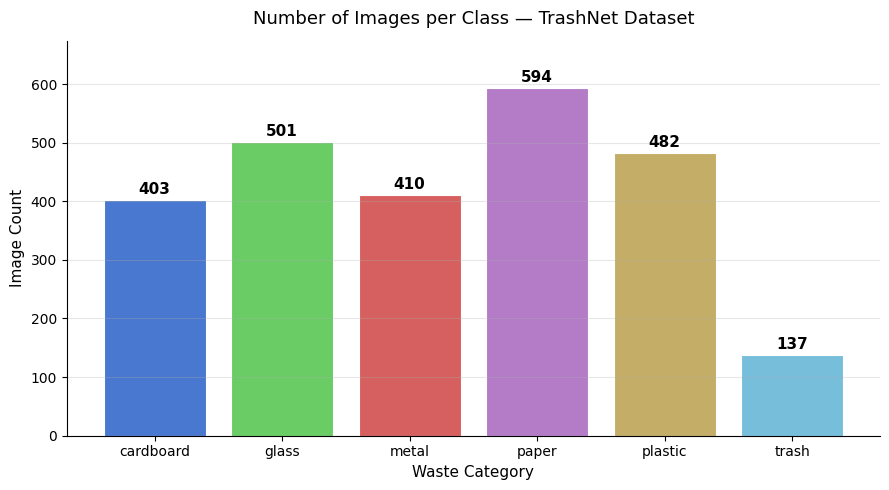

In [9]:
# Bar chart distribusi kelas
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66', '#77BEDB']
bars = ax.bar(classes_list, counts, color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("Number of Images per Class — TrashNet Dataset", fontsize=13, pad=12)
ax.set_xlabel("Waste Category", fontsize=11)
ax.set_ylabel("Image Count", fontsize=11)
ax.set_ylim(0, max(counts) + 80)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

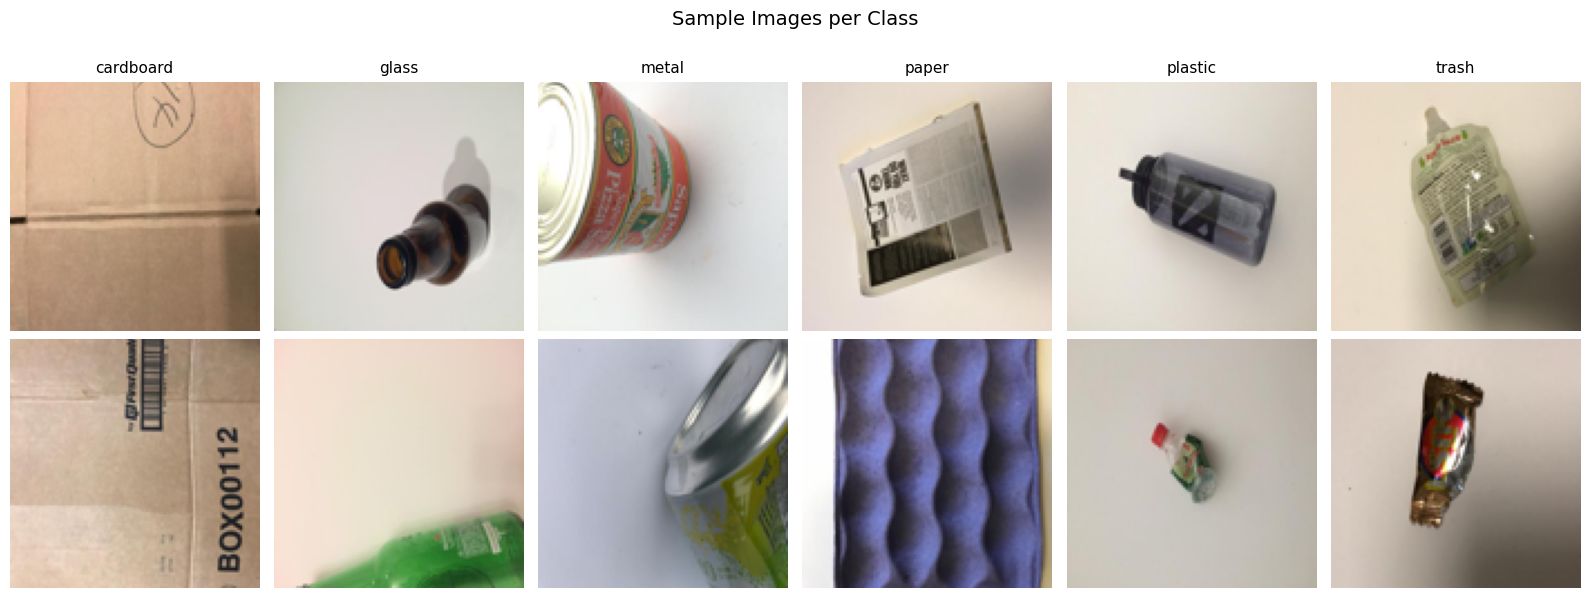

In [10]:
# Sample images per class (2 per class)
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle("Sample Images per Class", fontsize=14, y=1.01)

for col, cls in enumerate(classes_list):
    cls_dir = os.path.join(DATASET_PATH, cls)
    imgs = sorted(os.listdir(cls_dir))[:2]
    for row, fname in enumerate(imgs):
        img = Image.open(os.path.join(cls_dir, fname)).resize((112, 112))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(cls, fontsize=11)

plt.tight_layout()
plt.show()

In [11]:
# Check sample image size
sample_cls = classes_list[0]
sample_img_path = os.path.join(DATASET_PATH, sample_cls, os.listdir(os.path.join(DATASET_PATH, sample_cls))[0])
img_sample = np.array(Image.open(sample_img_path))
print(f"Sample image shape  : {img_sample.shape}")
print(f"Pixel value range   : [{img_sample.min()}, {img_sample.max()}]")
print(f"Dataset path        : {DATASET_PATH}")

Sample image shape  : (384, 512, 3)
Pixel value range   : [9, 255]
Dataset path        : /content/dataset-resized


## 3. Data Preprocessing

Preprocessing yang diterapkan:

1. **Resizing** — semua gambar di-resize ke 224×224 piksel agar kompatibel dengan MobileNetV2
2. **Normalization** — pixel values di-rescale dari [0, 255] ke [0, 1] menggunakan `rescale=1./255`
3. **Data Splitting** — dataset dibagi 80% training dan 20% validation menggunakan `validation_split=0.2`
4. **Data Augmentation** (training set saja):
   - `rotation_range=20` — rotasi acak ±20 derajat
   - `zoom_range=0.2` — zoom in/out acak hingga 20%
   - `horizontal_flip=True` — flip horizontal acak
   
   Augmentasi hanya diterapkan pada data training untuk memperbesar variasi data tanpa mempengaruhi evaluasi.

In [12]:
IMG_SIZE = 224
BATCH_SIZE = 32

# Generator untuk training (dengan augmentasi)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Generator untuk validasi (hanya rescale, tanpa augmentasi)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_data = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print("\nClass index mapping:")
print(train_data.class_indices)
print(f"\nTraining samples  : {train_data.samples}")
print(f"Validation samples: {val_data.samples}")
print(f"Number of classes : {train_data.num_classes}")

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.

Class index mapping:
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

Training samples  : 2024
Validation samples: 503
Number of classes : 6


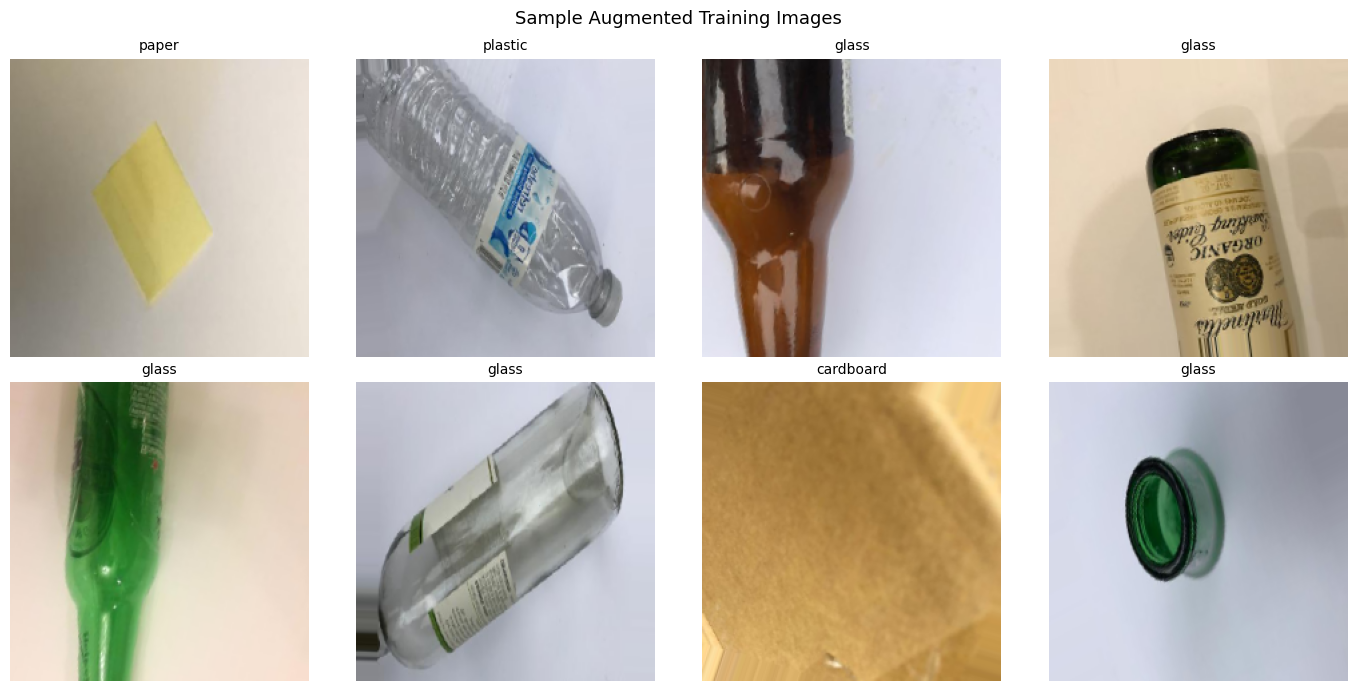

In [13]:
# Visualisasi augmented images
images, labels = next(train_data)
class_names = list(train_data.class_indices.keys())

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Sample Augmented Training Images", fontsize=13)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])
    label_idx = np.argmax(labels[i])
    ax.set_title(class_names[label_idx], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Baseline CNN Model

Sebelum menggunakan transfer learning, dibuat terlebih dahulu baseline CNN yang dilatih dari scratch. Model ini digunakan sebagai pembanding untuk mengukur seberapa besar peningkatan yang diberikan oleh transfer learning.

Arsitektur baseline:
- 3 blok Conv2D + MaxPooling2D (filter: 32, 64, 128)
- Flatten + Dense(128) + Dropout(0.5)
- Output: Dense(6, softmax)

In [14]:
baseline_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
], name="Baseline_CNN")

baseline_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
print("Training Baseline CNN...")
history_baseline = baseline_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    verbose=1
)
print("\nBaseline training complete.")

Training Baseline CNN...
Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 494ms/step - accuracy: 0.2633 - loss: 1.9094 - val_accuracy: 0.3598 - val_loss: 1.5463
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 407ms/step - accuracy: 0.4027 - loss: 1.4477 - val_accuracy: 0.3817 - val_loss: 1.5356
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 442ms/step - accuracy: 0.4392 - loss: 1.3820 - val_accuracy: 0.4453 - val_loss: 1.3820
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 413ms/step - accuracy: 0.4708 - loss: 1.3081 - val_accuracy: 0.4314 - val_loss: 1.3935
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 414ms/step - accuracy: 0.4812 - loss: 1.3050 - val_accuracy: 0.4612 - val_loss: 1.3514
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 414ms/step - accuracy: 0.4916 - loss: 1.2668 - val_accuracy: 0.4573 - val_loss: 1.4534
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 405ms/step - accuracy: 0.5459 - loss: 1.1866 - val_accuracy: 0.4712 - val_loss: 1.2764
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 410ms/step - accuracy: 0.5746 

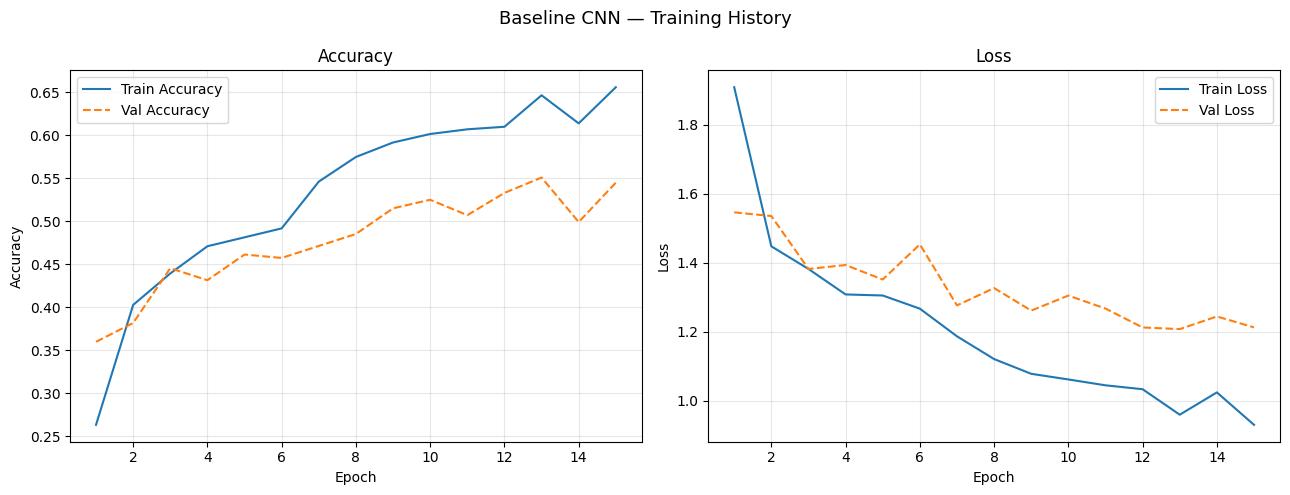

Final train accuracy : 0.6556
Final val accuracy   : 0.5447


In [16]:
# Plot baseline training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Baseline CNN — Training History", fontsize=13)

epochs_baseline = range(1, len(history_baseline.history['accuracy']) + 1)

axes[0].plot(epochs_baseline, history_baseline.history['accuracy'], label='Train Accuracy')
axes[0].plot(epochs_baseline, history_baseline.history['val_accuracy'], label='Val Accuracy', linestyle='--')
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_baseline, history_baseline.history['loss'], label='Train Loss')
axes[1].plot(epochs_baseline, history_baseline.history['val_loss'], label='Val Loss', linestyle='--')
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final values
final_train_acc = history_baseline.history['accuracy'][-1]
final_val_acc   = history_baseline.history['val_accuracy'][-1]
print(f"Final train accuracy : {final_train_acc:.4f}")
print(f"Final val accuracy   : {final_val_acc:.4f}")

## 5. Transfer Learning — MobileNetV2

Baseline CNN menunjukkan keterbatasan akurasi karena dataset yang relatif kecil (~2,500 gambar). Untuk meningkatkan performa, digunakan **transfer learning** dengan MobileNetV2.

**Alasan memilih MobileNetV2:**
- Pre-trained pada ImageNet (1.2M+ gambar) — fitur visual umum (tepi, tekstur, bentuk) sudah dipelajari
- Arsitektur ringan menggunakan depthwise separable convolutions — efisien secara komputasi
- Input size 224×224 sesuai dengan pipeline preprocessing yang sudah ditetapkan
- Ideal untuk dataset kecil karena backbone di-freeze, hanya classification head yang dilatih

**Konfigurasi:**
- `base_model.trainable = False` — weights backbone tidak diubah
- Ditambahkan: GlobalAveragePooling2D → Dense(128, relu) → Dropout(0.5) → Dense(6, softmax)

In [17]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
], name="MobileNetV2_Transfer")

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f"\nTrainable params  : {sum(v.numpy().size for v in model.trainable_variables):,}")
print(f"Frozen params     : {sum(v.numpy().size for v in model.non_trainable_variables):,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable params  : 164,742
Frozen params     : 2,257,986


In [18]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print("Training MobileNetV2 Transfer Learning model...")
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)
print("\nTraining complete.")

Training MobileNetV2 Transfer Learning model...
Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 71s 833ms/step - accuracy: 0.5870 - loss: 1.1022 - val_accuracy: 0.6720 - val_loss: 0.8167 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 398ms/step - accuracy: 0.7396 - loss: 0.7160 - val_accuracy: 0.7396 - val_loss: 0.6976 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 395ms/step - accuracy: 0.7782 - loss: 0.6178 - val_accuracy: 0.7396 - val_loss: 0.6341 - learning_rate: 0.0010
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 409ms/step - accuracy: 0.7974 - loss: 0.5501 - val_accuracy: 0.7515 - val_loss: 0.6434 - learning_rate: 0.0010
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 398ms/step - accuracy: 0.8177 - loss: 0.4773 - val_accuracy: 0.7594 - val_loss: 0.6272 - learning_rate: 0.0010
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 399ms/step - accuracy: 0.8365 - loss: 0.4591 - val_accuracy: 0.7515 - val_loss: 0.6091 - learning_rate: 0.0010
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━

## 6. Training and Validation Results

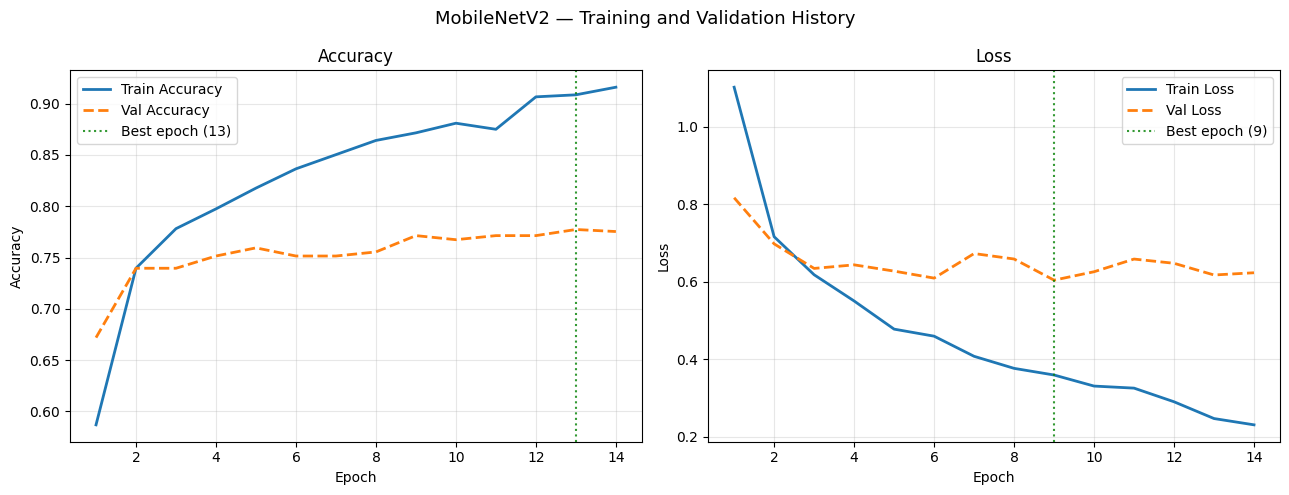

MobileNetV2 Training Summary:
  Best val accuracy : 0.7773 (epoch 13)
  Best val loss     : 0.6038 (epoch 9)
  Final train acc   : 0.9160
  Final val acc     : 0.7753


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("MobileNetV2 — Training and Validation History", fontsize=13)

epochs_range = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(epochs_range, history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy',
             linestyle='--', linewidth=2)
best_ep = int(np.argmax(history.history['val_accuracy'])) + 1
axes[0].axvline(best_ep, color='green', linestyle=':', alpha=0.8,
                label=f'Best epoch ({best_ep})')
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(epochs_range, history.history['val_loss'], label='Val Loss',
             linestyle='--', linewidth=2)
best_ep_loss = int(np.argmin(history.history['val_loss'])) + 1
axes[1].axvline(best_ep_loss, color='green', linestyle=':', alpha=0.8,
                label=f'Best epoch ({best_ep_loss})')
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("MobileNetV2 Training Summary:")
print(f"  Best val accuracy : {max(history.history['val_accuracy']):.4f} (epoch {best_ep})")
print(f"  Best val loss     : {min(history.history['val_loss']):.4f} (epoch {best_ep_loss})")
print(f"  Final train acc   : {history.history['accuracy'][-1]:.4f}")
print(f"  Final val acc     : {history.history['val_accuracy'][-1]:.4f}")

In [20]:
# Comparison table: Baseline vs MobileNetV2
val_loss_b, val_acc_b = baseline_model.evaluate(val_data, verbose=0)
val_loss_m, val_acc_m = model.evaluate(val_data, verbose=0)

print("Model Comparison — Validation Set:")
print(f"{'Model':<25} {'Val Accuracy':>14} {'Val Loss':>12}")
print("-" * 53)
print(f"{'Baseline CNN':<25} {val_acc_b:>14.4f} {val_loss_b:>12.4f}")
print(f"{'MobileNetV2 Transfer':<25} {val_acc_m:>14.4f} {val_loss_m:>12.4f}")
print(f"{'Improvement':<25} {val_acc_m - val_acc_b:>+14.4f} {val_loss_m - val_loss_b:>+12.4f}")

Model Comparison — Validation Set:
Model                       Val Accuracy     Val Loss
-----------------------------------------------------
Baseline CNN                      0.5447       1.2125
MobileNetV2 Transfer              0.7714       0.6038
Improvement                      +0.2266      -0.6086


## 7. Evaluation Results

Evaluasi dilakukan menggunakan metrik:
- **Classification Report** — precision, recall, F1-score per kelas
- **Confusion Matrix** — visualisasi distribusi prediksi vs label aktual
- **ROC Curve & AUC** — kemampuan model memisahkan antar kelas

In [21]:
# Predict on validation set
val_data.reset()
predictions_prob = model.predict(val_data, verbose=0)
predicted_classes = np.argmax(predictions_prob, axis=1)
true_classes = val_data.classes
class_labels = list(val_data.class_indices.keys())

print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels, digits=4))

Classification Report:
              precision    recall  f1-score   support

   cardboard     0.9375    0.7500    0.8333        80
       glass     0.7604    0.7300    0.7449       100
       metal     0.7527    0.8537    0.8000        82
       paper     0.8182    0.9153    0.8640       118
     plastic     0.6635    0.7188    0.6900        96
       trash     0.5714    0.2963    0.3902        27

    accuracy                         0.7714       503
   macro avg     0.7506    0.7107    0.7204       503
weighted avg     0.7722    0.7714    0.7664       503



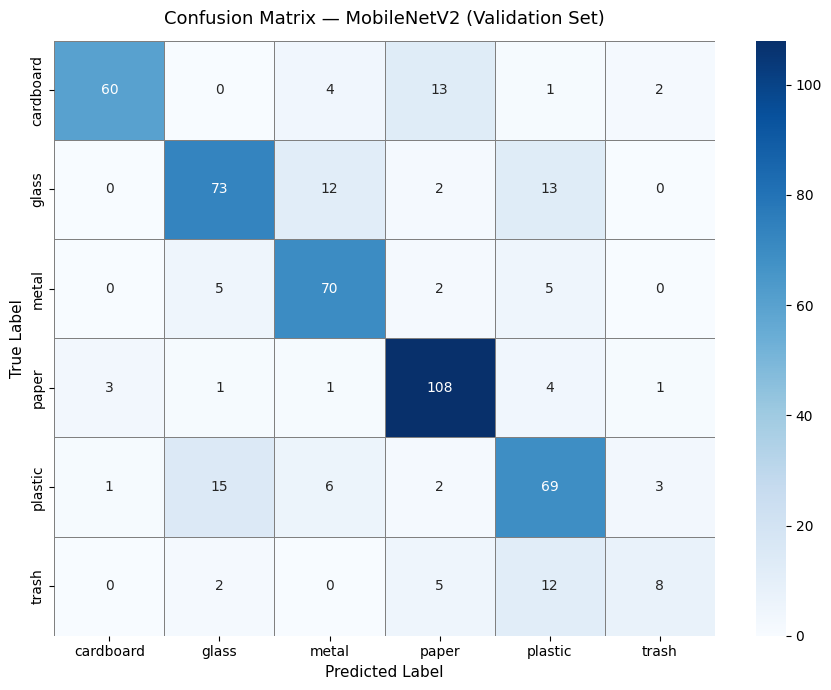

In [22]:
# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_labels, yticklabels=class_labels,
    linewidths=0.5, linecolor='gray'
)
ax.set_title("Confusion Matrix — MobileNetV2 (Validation Set)", fontsize=13, pad=12)
ax.set_ylabel("True Label", fontsize=11)
ax.set_xlabel("Predicted Label", fontsize=11)
plt.tight_layout()
plt.show()

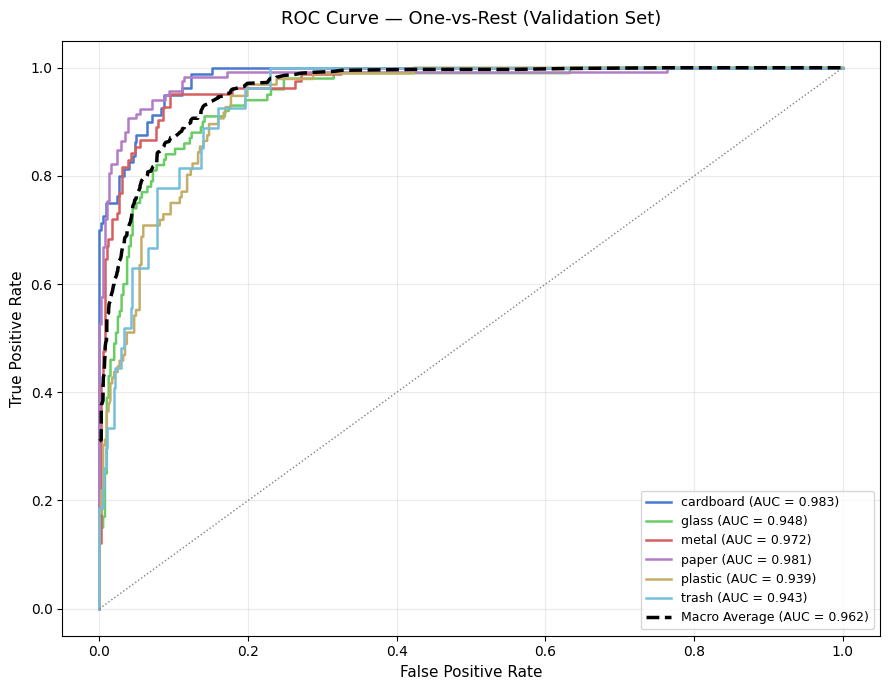

Per-class AUC Scores:
  cardboard   : 0.9831
  glass       : 0.9475
  metal       : 0.9720
  paper       : 0.9807
  plastic     : 0.9394
  trash       : 0.9427
  Macro AUC   : 0.9617


In [23]:
# ROC Curve (One-vs-Rest, macro average)
n_classes = len(class_labels)
true_binarized = label_binarize(true_classes, classes=list(range(n_classes)))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(true_binarized[:, i], predictions_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)

fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66', '#77BEDB']
for i, (cls, color) in enumerate(zip(class_labels, colors_roc)):
    ax.plot(fpr[i], tpr[i], color=color, linewidth=1.8,
            label=f"{cls} (AUC = {roc_auc[i]:.3f})")

ax.plot(all_fpr, mean_tpr, color='black', linewidth=2.5, linestyle='--',
        label=f"Macro Average (AUC = {macro_auc:.3f})")
ax.plot([0, 1], [0, 1], 'gray', linestyle=':', linewidth=1)
ax.set_title("ROC Curve — One-vs-Rest (Validation Set)", fontsize=13, pad=12)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print("Per-class AUC Scores:")
for i, cls in enumerate(class_labels):
    print(f"  {cls:12s}: {roc_auc[i]:.4f}")
print(f"  {'Macro AUC':12s}: {macro_auc:.4f}")

## 8. Grad-CAM Visualization

Grad-CAM (Gradient-weighted Class Activation Mapping) diimplementasikan untuk memberikan interpretabilitas pada model. Grad-CAM menghitung gradien dari skor kelas terhadap feature map layer konvolusi terakhir, menghasilkan heatmap yang menunjukkan area gambar yang paling mempengaruhi prediksi.

In [29]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    backbone = model.layers[0]

    # Build grad model explicitly using backbone input
    conv_layer = backbone.get_layer(last_conv_layer_name)

    grad_model = tf.keras.models.Model(
        inputs=[backbone.input],
        outputs=[conv_layer.output, backbone.output]
    )

    # Full model head (after backbone)
    @tf.function
    def get_prediction_and_grads(img):
        with tf.GradientTape() as tape:
            conv_out, backbone_out = grad_model(img)
            # Pass through the rest of the model manually
            x = model.layers[1](backbone_out)  # GlobalAveragePooling2D
            x = model.layers[2](x)             # Dense 128
            x = model.layers[3](x)             # Dropout
            predictions = model.layers[4](x)   # Dense 6 softmax

            if pred_index is None:
                idx = tf.argmax(predictions[0])
            else:
                idx = pred_index
            class_channel = predictions[:, idx]

        grads = tape.gradient(class_channel, conv_out)
        return conv_out, grads, predictions

    conv_outputs, grads, predictions = get_prediction_and_grads(img_array)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


def overlay_gradcam(img_path, heatmap, alpha=0.4):
    """Superimpose Grad-CAM heatmap on original image."""
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    superimposed = heatmap_colored * alpha + img
    superimposed = np.clip(superimposed, 0, 255).astype("uint8")

    return cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)

print("Grad-CAM helper functions defined.")

Grad-CAM helper functions defined.


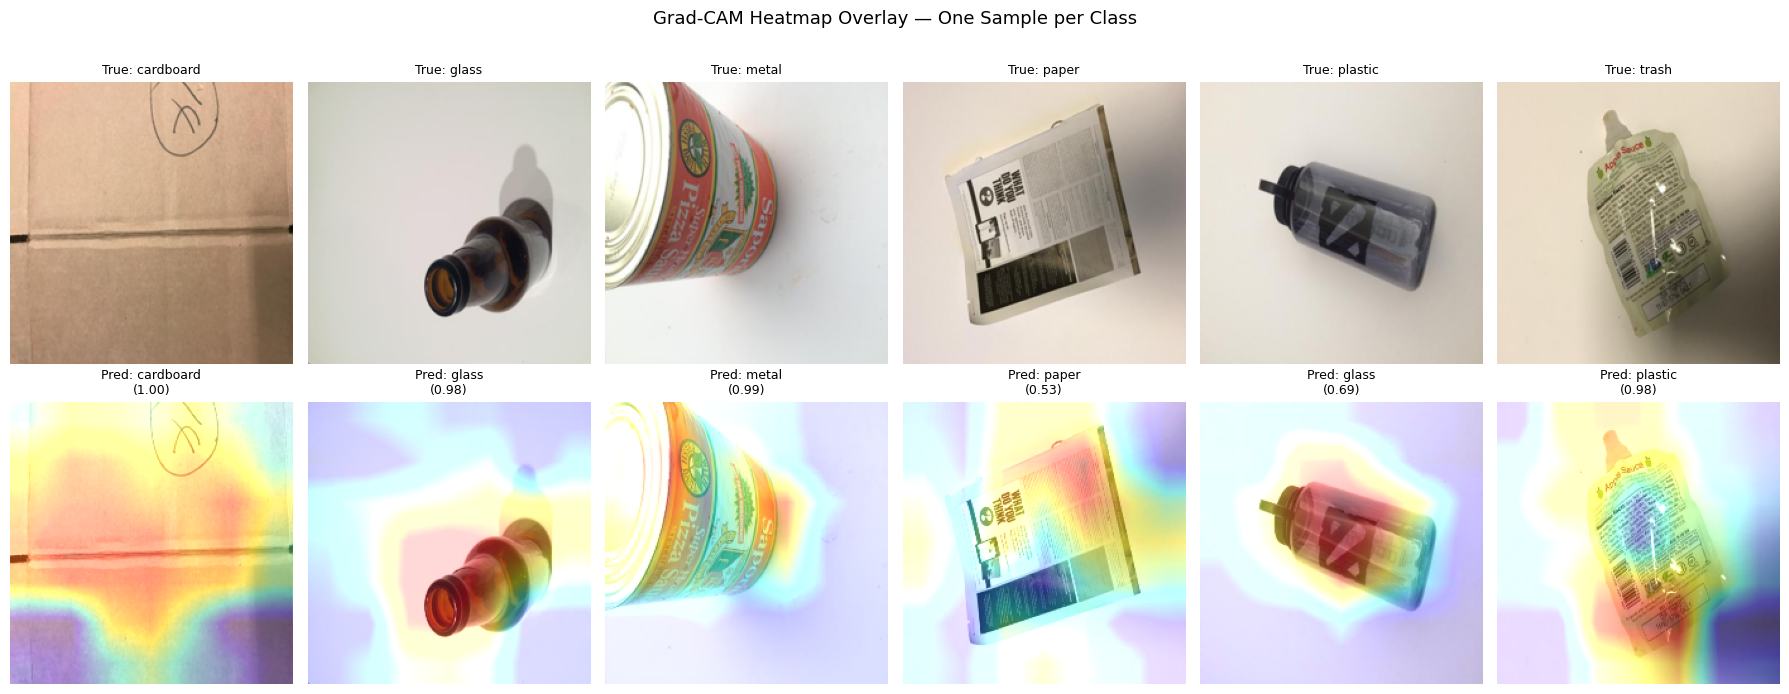

In [30]:
# Run Grad-CAM on 6 sample images (one per class)
LAST_CONV = "Conv_1"  # Last conv layer in MobileNetV2 backbone

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.suptitle("Grad-CAM Heatmap Overlay — One Sample per Class", fontsize=13, y=1.01)

for col, cls in enumerate(class_labels):
    cls_dir = os.path.join(DATASET_PATH, cls)
    img_files = sorted(os.listdir(cls_dir))
    img_path = os.path.join(cls_dir, img_files[0])

    # Load and preprocess image
    img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img) / 255.0
    img_input = np.expand_dims(img_array, axis=0).astype(np.float32)

    # Predict
    preds = model.predict(img_input, verbose=0)
    pred_idx = np.argmax(preds[0])
    pred_label = class_labels[pred_idx]
    confidence = preds[0][pred_idx]

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_input, model, LAST_CONV, pred_index=pred_idx)
    overlay = overlay_gradcam(img_path, heatmap)

    # Original
    axes[0][col].imshow(img)
    axes[0][col].set_title(f"True: {cls}", fontsize=9)
    axes[0][col].axis('off')

    # Grad-CAM overlay
    axes[1][col].imshow(overlay)
    axes[1][col].set_title(f"Pred: {pred_label}\n({confidence:.2f})", fontsize=9)
    axes[1][col].axis('off')

plt.tight_layout()
plt.show()

### Grad-CAM Analysis

Grad-CAM berhasil memvisualisasikan area fokus model untuk setiap prediksi. Beberapa observasi:

- Pada kelas **metal**, heatmap terfokus pada tepi silindris dan permukaan metalik objek
- Pada kelas **paper** dan **cardboard**, model fokus pada tepi kotak dan tekstur permukaan
- Pada kelas **glass**, fokus terpusat pada area transparan atau pantulan cahaya
- Kelas **trash** menunjukkan pola fokus yang lebih tersebar, konsisten dengan keragaman visual tinggi pada kelas ini

Hal ini mengkonfirmasi bahwa model belajar fitur visual yang relevan untuk klasifikasi, bukan bergantung pada background gambar.